In [12]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

In [13]:
def Show_Image(images):
    for image in images:
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()

## Bài 1 - Biểu diễn dữ liệu thành ma trận & Độ tương đồng

### 1. Chuyển đổi hình ảnh sang ma trận
Do tập dữ liệu chứa **8 ảnh có kích thước khác nhau**, quy trình xử lý được thực hiện theo các bước sau:

* **Bước 1:** Thay đổi kích thước toàn bộ ảnh về cùng một size tiêu chuẩn (`resize`) và lưu vào một danh sách (`list`).
* **Bước 2:** Làm phẳng (`flatten`) ma trận của từng ảnh từ 2D/3D thành vector 1D.
* **Bước 3:** Gộp 8 vector này lại để tạo thành một **ma trận dữ liệu tổng hợp** duy nhất.

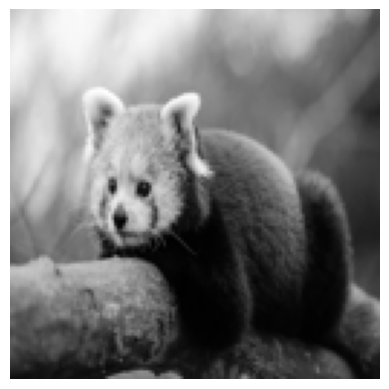

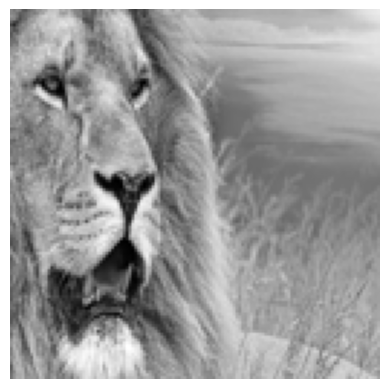

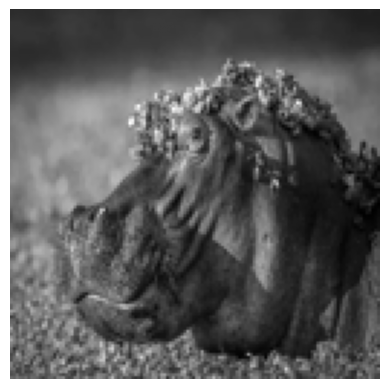

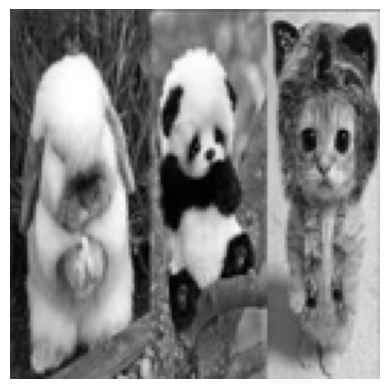

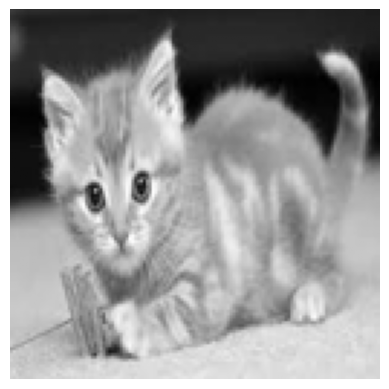

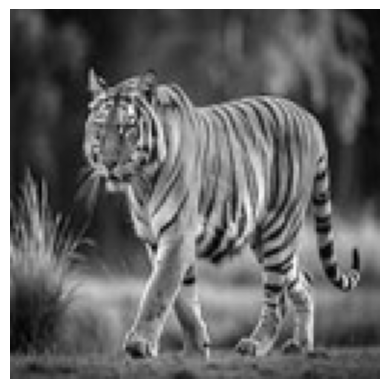

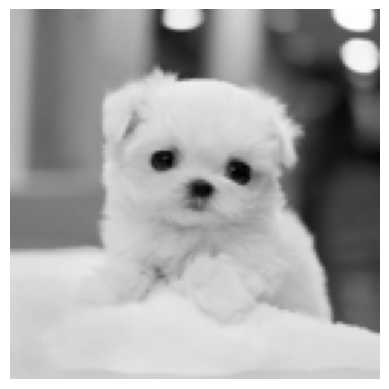

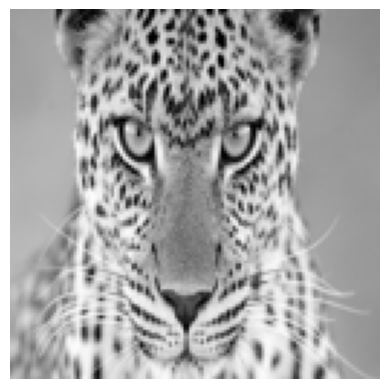

[[195. 199. 203. ...  15.  20.  20.]
 [128. 113. 128. ... 191. 183. 157.]
 [ 42.  42.  42. ...  87.  64.  65.]
 ...
 [ 62.  60.  66. ...  57.  57.  47.]
 [185. 185. 183. ... 204. 204. 204.]
 [155. 155. 155. ... 166. 161. 157.]]
(8, 16384)


In [14]:
root_dir = "/kaggle/input/datasets/tinphan2007/week1-stt/WEEK1_ĐSTT"
def Read_Image(root_dir):
    images = []
    flat_vectors = []
    for image_name in sorted(os.listdir(root_dir)):
        image_dir = os.path.join(root_dir, image_name)
        image = Image.open(image_dir).convert("L")
        image_np = np.array(image.resize((128, 128)), dtype = float)
        H,W = image_np.shape
        flat_vector = image_np.reshape(H*W)
        images.append(image_np)
        flat_vectors.append(flat_vector)
    return images, flat_vectors

image_list, flat_vectors = Read_Image(root_dir)
image_matrix = np.array(flat_vectors)
Show_Image(images=image_list)

print(image_matrix)
print(image_matrix.shape)

### 2. Phép toán cơ bản.
Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting.

In [15]:
###Ma tran trung binh theo cot
matrix_mean = image_matrix.mean(axis=0)
print(matrix_mean.shape)

###Ma tran sau khi tru
new_matrix = image_matrix - matrix_mean
print(new_matrix.shape)

(16384,)
(8, 16384)


### 3. Cosine similarity.
Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [16]:
def cosine_similarity(X, Y=None):
    X_flat = X.reshape(1, -1)
    X_norm = X_flat / np.linalg.norm(X_flat, axis=1, keepdims=True)
    
    if Y is None:
        Y_norm = X_norm
    else:
        Y_flat = Y.reshape(1, -1)
        Y_norm = Y_flat / np.linalg.norm(Y_flat, axis=1, keepdims=True)
        
    result = np.dot(X_norm, Y_norm.T)
    return np.squeeze(result)

### 4. Truy vấn.
Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất
kèm điểm cosine.

In [17]:
def search_query(query, top_k=3):
    results = []
    for i, image in enumerate(image_list):
        cos_score = cosine_similarity(image, query).item()
        results.append((i, cos_score))

    results = sorted(results, key=lambda x: x[1], reverse=True)
    return results[:top_k]

### 5. Nhận xét.
Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp trực giác không?

In [18]:
def nhan_xet(images):
    max_score = -2.0
    min_score = 2.0
    best_pair = (None, None)
    worst_pair = (None, None)
    
    for i in range(len(images)):
        for j in range(i + 1, len(images)):
            score = cosine_similarity(images[i], images[j]).item()
            
            if score > max_score:
                max_score = score
                best_pair = (i, j)
                
            if score < min_score:
                min_score = score
                worst_pair = (i, j)
                
    return (best_pair, max_score), (worst_pair, min_score)

max_res, min_res = nhan_xet(image_list)

print(f"Ảnh số {max_res[0][0]} và Ảnh số {max_res[0][1]} giống nhau nhất.")
print(f"Điểm số Cosine Similarity đạt: {max_res[1]:.4f}")
print(f"Ảnh số {min_res[0][0]} và Ảnh số {min_res[0][1]} khác nhau nhất.")
print(f"Điểm số Cosine Similarity đạt: {min_res[1]:.4f}")

Ảnh số 1 và Ảnh số 7 giống nhau nhất.
Điểm số Cosine Similarity đạt: 0.9218
Ảnh số 0 và Ảnh số 4 khác nhau nhất.
Điểm số Cosine Similarity đạt: 0.6636


## Bài 2 — Biến đổi tuyến tính & SVD
### 1. Biến đổi tuyến tính.

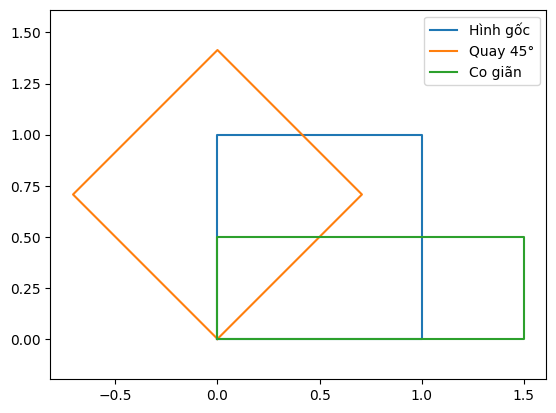

In [19]:
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta), np.cos(theta)]])
S = np.array([[1.5, 0.0], 
              [0.0, 0.5]])
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])
rotated = R @ square
scaled = S @ square

plt.plot(square[0, :], square[1, :], label='Hình gốc')
plt.plot(rotated[0, :], rotated[1, :], label='Quay 45°')
plt.plot(scaled[0, :], scaled[1, :], label='Co giãn')

plt.axis('equal')
plt.legend()
plt.show()

### 2. Nén ảnh bằng SVD.
Phân rã $M = U\Sigma V^T$; giữ lại k giá trị kỳ dị lớn nhất (thử
k = 5, 20, 50), tái tạo và hiển thị ảnh để so sánh.

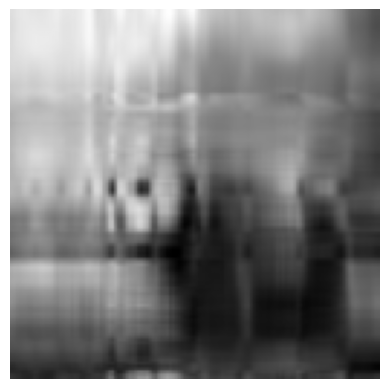

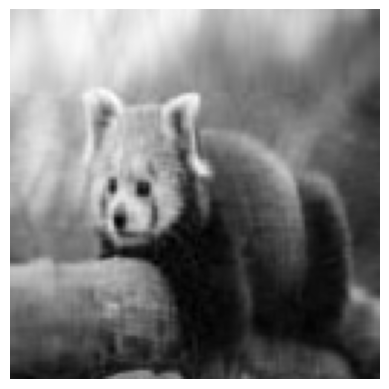

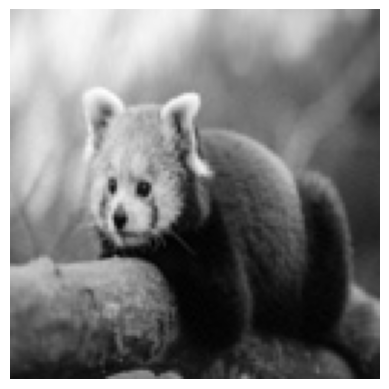

In [20]:
img_example = image_list[0]
U, S, Vt = np.linalg.svd(img_example, full_matrices = False)
def reconstruct(k):
    return ( U [:,:k] * S [:k]) @ Vt [:k,:]
k_values = [5, 20, 50]
reconstructed_images = [reconstruct(k) for k in k_values]

Show_Image(reconstructed_images)

### 3. Đánh giá.
Tính tỉ lệ nén và sai số tái tạo theo từng k; vẽ đồ thị sai số theo k.

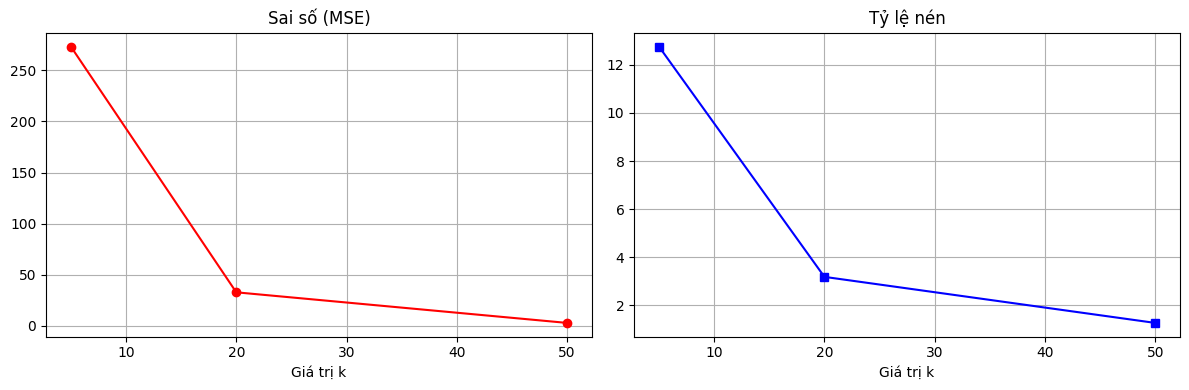

In [21]:
errors = []
compression_ratios = []
H, W = img_example.shape
original_size = H*W

for k, img in zip(k_values, reconstructed_images):
    # Tinh sai so (MSE)
    mse = np.mean((img_example-img)**2)
    errors.append(mse)

    # Tính tỷ lệ nén
    # Kích thước sau nén = k * H (của U) + k (của S) + k * W (của V) = k(H + W + 1)
    compressed_size = k * (H + W + 1)
    ratio = original_size / compressed_size
    compression_ratios.append(ratio)

# Ve do thi sai so theo k
plt.figure(figsize=(12, 4))
data = [(errors, 'Sai số (MSE)', 'red', 'o'), (compression_ratios, 'Tỷ lệ nén', 'blue', 's')]

for i, (y_data, title, color, marker) in enumerate(data, 1):
    plt.subplot(1, 2, i)
    plt.plot(k_values, y_data, marker=marker, color=color)
    plt.title(title)
    plt.xlabel('Giá trị k')
    plt.grid(True)

plt.tight_layout()
plt.show()

### 4. Nhận xét.
#### Kết luận: Ảnh bắt đầu chấp nhận được tại \(k = 20\).
Lý do: Từ \(k = 20\) đến \(k = 50\), đồ thị sai số (MSE) dốc ít. Điều này chứng tỏ tại \(k = 20\), ảnh đã giữ được hầu hết các đặc trưng cốt lõi. Việc tăng lên \(k = 50\) giúp giảm sai số không đáng kể nhưng lại làm tăng dung lượng lưu trữ (giảm hiệu quả nén).
#### Liên hệ với giảm chiều và nén dữ liệu trong AI
Việc chọn \(k = 20\) tương tự như thuật toán PCA trong AI. Nó giúp loại bỏ các thông tin nhiễu, chi tiết thừa để giữ lại các đặc trưng quan trọng nhất, giúp mô hình AI tính toán nhanh hơn và tránh overfitting.

### 5. Bonus.
#### Vẽ đồ thị năng lượng tích lũy của các giá trị kỳ dị và chọn k giữ ≥ 90% thông tin.

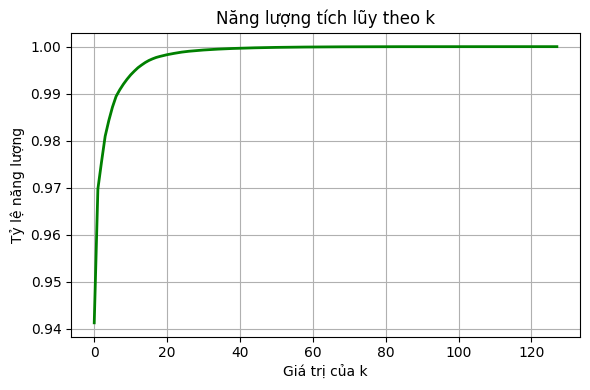

Để giữ lại >= 90% thông tin, cần k = 1


In [22]:
# Tinh nang luong tich luy
total_energy = np.sum(S ** 2)
cumulative_energy = np.cumsum(S ** 2) / total_energy

k_90 = np.argmax(cumulative_energy >= 0.90) + 1

plt.figure(figsize=(6, 4))

plt.plot(cumulative_energy, color='green', linewidth=2)
plt.title('Năng lượng tích lũy theo k')
plt.xlabel('Giá trị của k')
plt.ylabel('Tỷ lệ năng lượng')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Để giữ lại >= 90% thông tin, cần k = {k_90}")